In [5]:
import numpy as np
import matplotlib.pyplot as plt

import utils

In [6]:
data_dir = "./data/BioUSElective_20260506_JTLRYTAA/ST/"
filepath = data_dir + "data_20260506_164831_ST_5.9Vmat_20260506_165551.mat"

BFData, ReconParams = utils.extract_mat_file(filepath)

Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64


In [25]:
def plot_beamformed_image(BFData, ReconParams, mode='BMode', figsize=(10, 8),
                          cmap='bone', show_colorbar=True,
                          IMG_max=None, IMG_min=None, db_range=45, full_db_range=False):
    mode = mode.lower()
    if mode == 'am':
        iq_data = BFData.get('IQ_xAM')
        title = 'Log‑compressed IQ_xAM'
    elif mode == 'bmode':
        iq_data = BFData.get('IQ_xBMode')
        title = 'Log‑compressed IQ_xBMode'
    else:
        raise ValueError("mode must be 'AM' or 'BMode'")

    if iq_data is None:
        raise KeyError(f"Data for mode {mode} not found in BFData")

    #envelope = # TAKE THE ENVELOPE
    envelope = np.abs(iq_data)
    envelope = envelope.T
    
    #log-compression
    if IMG_max is None:
        IMG_max = np.max(envelope)
    log_env = 20 * np.log10(envelope / IMG_max)        # hide only part of the log-compression formula, tell them to look at slide 30 of 06 - Medical Ultrasound Slides
    if IMG_min is None:
        min_db = -db_range
    else: #IMG_min / IMG_max
        min_db = 20 * np.log10(IMG_min / IMG_max)
    
    if full_db_range==True #np.min(envelope) / np.max(envelope)
        min_db = 20 * np.log10(np.min(envelope) / np.max(envelope))
        
    img_compressed = np.clip(log_env, min_db, 0)

    # Physical axes (meters -> mm)
    grid_origin = ReconParams['GridOrigin']
    grid_scale_x = ReconParams['GridScaleX'] 
    grid_scale_z = ReconParams['GridScaleZ']

    n_depth, n_lateral = iq_data.shape
    lateral_mm = (grid_origin[0] + np.arange(n_lateral) * grid_scale_x) * 1000
    depth_mm  = (grid_origin[2] + np.arange(n_depth)  * grid_scale_z) * 1000
    depth_mm = np.flip(depth_mm)
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(img_compressed,
                   extent=[lateral_mm[0], lateral_mm[-1], depth_mm[0], depth_mm[-1]],
                   aspect='equal',
                   cmap=cmap,
                   vmin=min_db, vmax=0)          # set dB range explicitly
    ax.set_ylabel('Depth (mm)')
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, label='Amplitude (dB)')   # now labels dB correctly

    plt.tight_layout()
    return img_compressed, envelope, lateral_mm, depth_mm

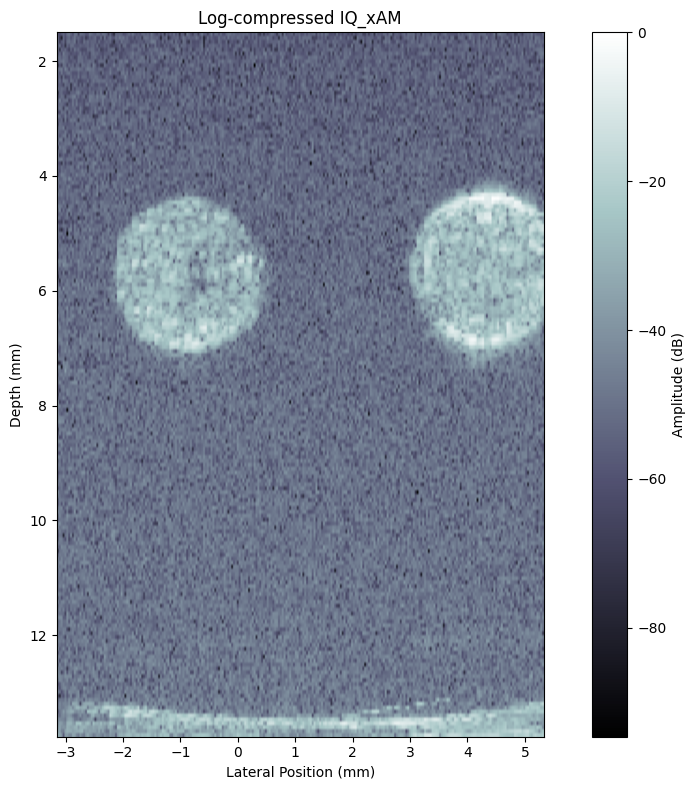

In [34]:
# Example usage:
img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', full_db_range=True)
# fig2, ax2 = plot_beamformed_image(BFData, ReconParams, mode='BMode')

In [27]:
def extract_subimage(image, depth_range, lateral_range, plot=True, db_range=45, IMG_min=None, IMG_max=None):
    """
    Extract a submatrix from a 2D image defined by index ranges and optionallyenvelope
    plot the original image with the submatrix region highlighted.

    Parameters
    ----------
    image : np.ndarray
        2D array of shape (depth, lateral) = (rows, columns).
    depth_range : tuple (int, int)
        Start and end indices for the depth (row) dimension. Supports
        both inclusive (closed) and half‑open intervals.
    lateral_range : tuple (int, int)
        Start and end indices for the lateral (column) dimension.
        Behaves similarly to depth_range.
    plot : bool, optional
        If True, display the original image with a red rectangle outlining
        the extracted submatrix. Default is True.

    Returns
    -------
    subimage : np.ndarray
        The extracted submatrix as a 2D array.
    """
    # Unpack ranges
    depth_start, depth_end = depth_range
    lat_start, lat_end = lateral_range

    depth_sub = slice(depth_start, depth_end + 1)
    lat_sub = slice(lat_start, lat_end + 1)

    subimage = image[depth_sub, lat_sub]

    #log-compression
    if IMG_max is None:
        IMG_max = np.max(image)
    log_env = 20 * np.log10(image / IMG_max)        # 0 at max    
    if IMG_min is None:
        min_db = -db_range
    else:
        min_db = 20 * np.log10(IMG_min / IMG_max)
    log_image = np.clip(log_env, min_db, 0)

    # Optional plotting
    if plot:
        plt.figure(figsize=(8, 6))
        # Plot the whole image
        plt.imshow(log_image, cmap='bone')
        plt.title("Original image with extracted region")

        # Draw rectangle: rectangle edges defined by (left, top, width, height)
        # Coordinates are in pixel indices.
        left = lat_start
        top = depth_start
        width = lat_end - lat_start + 1
        height = depth_end - depth_start + 1

        rect = plt.Rectangle((left, top), width, height,
                             linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)

        # Set aspect to auto to avoid distortion
        plt.gca().set_aspect(2.0)
        plt.show()

    return subimage


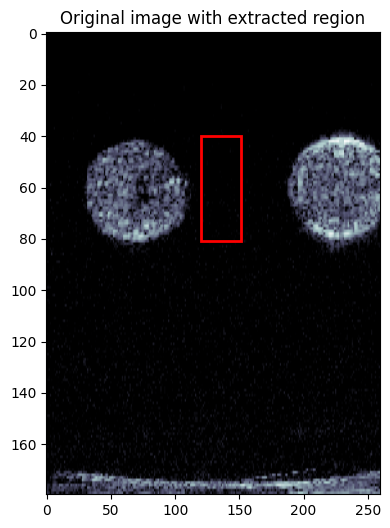

In [28]:
## Find the mean intensity of a background region

sub = extract_subimage(envelope, depth_range=(40, 80), lateral_range=(120, 150))

IMG_min =  

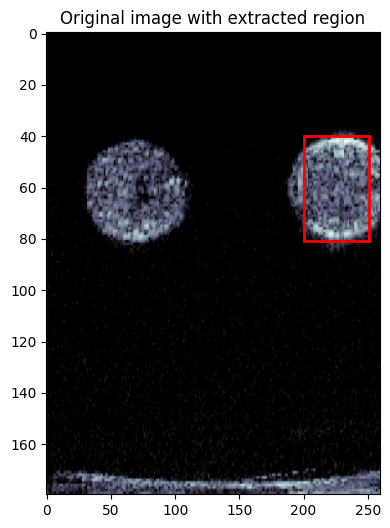

In [29]:
## Find the max intensity of a well

sub = extract_subimage(envelope, depth_range=(40, 80), lateral_range=(200, 250))

IMG_max = sub.max()

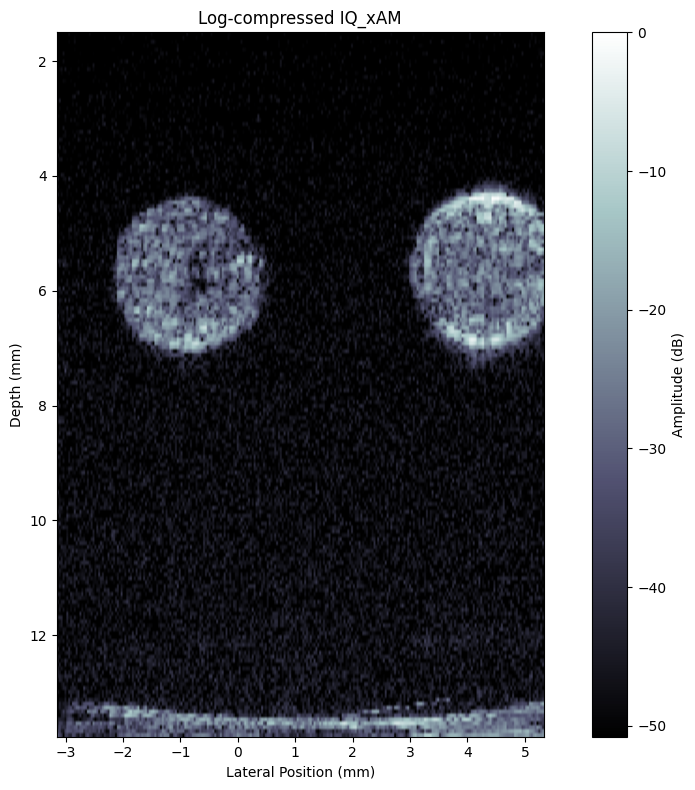

In [30]:
## Plot reconstruction with CNR based dynamic range

img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', IMG_min=IMG_min, IMG_max=IMG_max)

In [ ]:
# Compute CNR
cnr = 20 * np.log10(avg_background_region / max_well)

In [7]:
## Repeat CNR computation for all Stripped GV images

In [8]:
## Repeat CNR computation for all Wild Type GV images

In [9]:
import pandas as pd

# Provide the file path (adjust if needed)
file_path = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Jt_stripped_3_06052026.xlsx"

# Read all sheets into a dictionary of DataFrames
sheets_dict = pd.read_excel(file_path, sheet_name=None, header=0)

# # Iterate over each sheet and show its content
# for sheet_name, df in sheets_dict.items():
#     print(f"\n{'='*60}")
#     print(f"Sheet: {sheet_name}")
#     print(f"Shape: {df.shape}")
#     print(f"Columns: {list(df.columns)}")
#     print(df.head())  # Show first few rows

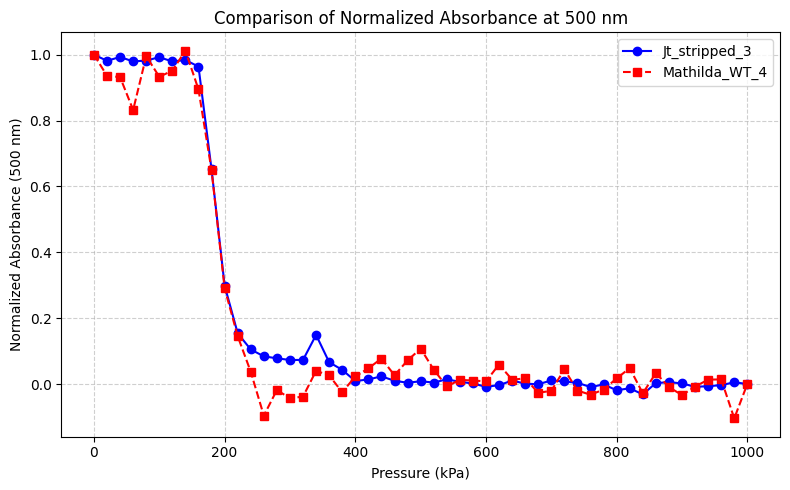

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# File path
file1 = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Jt_stripped_3_06052026.xlsx"
file2 = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Ira_stripped_6_06052026.xlsx"

# Read the "Normalized Abs 500" sheet from each file
df1 = pd.read_excel(file1, sheet_name="Normalized Abs 500")
df2 = pd.read_excel(file2, sheet_name="Normalized Abs 500")

# Plot both curves
plt.figure(figsize=(8, 5))
plt.plot(df1["Pressure (kPa)"], df1["Absorbance 500nm"], 
         marker='o', linestyle='-', color='blue', label="Jt_stripped_3")
plt.plot(df2["Pressure (kPa)"], df2["Absorbance 500nm"], 
         marker='s', linestyle='--', color='red', label="Mathilda_WT_4")

plt.xlabel("Pressure (kPa)")
plt.ylabel("Normalized Absorbance (500 nm)")
plt.title("Comparison of Normalized Absorbance at 500 nm")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()